In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rifatalam3/coffee-revenue-dataset/Coffe_sales.csv


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Machine Learning imports
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Time series forecasting
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")




# EXPLORE DATA

In [3]:


df = pd.read_csv('/kaggle/input/datasets/rifatalam3/coffee-revenue-dataset/Coffe_sales.csv')




##  Basic info

In [4]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Shape: 3547 rows, 11 columns


In [5]:
print(f"\nColumns: {list(df.columns)}")


Columns: ['hour_of_day', 'cash_type', 'money', 'coffee_name', 'Time_of_Day', 'Weekday', 'Month_name', 'Weekdaysort', 'Monthsort', 'Date', 'Time']


In [6]:
print(df.head())

   hour_of_day cash_type  money    coffee_name Time_of_Day Weekday Month_name  \
0           10      card   38.7          Latte     Morning     Fri        Mar   
1           12      card   38.7  Hot Chocolate   Afternoon     Fri        Mar   
2           12      card   38.7  Hot Chocolate   Afternoon     Fri        Mar   
3           13      card   28.9      Americano   Afternoon     Fri        Mar   
4           13      card   38.7          Latte   Afternoon     Fri        Mar   

   Weekdaysort  Monthsort        Date             Time  
0            5          3  2024-03-01  10:15:50.520000  
1            5          3  2024-03-01  12:19:22.539000  
2            5          3  2024-03-01  12:20:18.089000  
3            5          3  2024-03-01  13:46:33.006000  
4            5          3  2024-03-01  13:48:14.626000  


In [7]:
print(df.dtypes)

hour_of_day      int64
cash_type       object
money          float64
coffee_name     object
Time_of_Day     object
Weekday         object
Month_name      object
Weekdaysort      int64
Monthsort        int64
Date            object
Time            object
dtype: object


## BASIC STATISTICS

In [8]:
print(df.describe())

       hour_of_day        money  Weekdaysort    Monthsort
count  3547.000000  3547.000000  3547.000000  3547.000000
mean     14.185791    31.645216     3.845785     6.453905
std       4.234010     4.877754     1.971501     3.500754
min       6.000000    18.120000     1.000000     1.000000
25%      10.000000    27.920000     2.000000     3.000000
50%      14.000000    32.820000     4.000000     7.000000
75%      18.000000    35.760000     6.000000    10.000000
max      22.000000    38.700000     7.000000    12.000000


## MISSING VALUES

In [9]:
print(df.isnull().sum())

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64


#  DATA CLEANING & PREPARATION

In [10]:

# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

# Extract additional date features if needed
df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n Duplicate rows: {duplicates}")

# Check money column for any anomalies
print(f"\n Transaction amount range: ${df['money'].min():.2f} - ${df['money'].max():.2f}")



 Duplicate rows: 0

 Transaction amount range: $18.12 - $38.70


#  KEY METRICS & KPIs

In [11]:


total_revenue = df['money'].sum()
total_transactions = len(df)
avg_transaction_value = total_revenue / total_transactions
unique_coffee_types = df['coffee_name'].nunique()

# Check payment method distribution
payment_counts = df['cash_type'].value_counts()
print(f"\n Payment Methods Found: {list(payment_counts.index)}")

if len(payment_counts) == 2:
    card_percentage = (df['cash_type'] == 'card').mean() * 100
    cash_percentage = (df['cash_type'] == 'cash').mean() * 100
elif len(payment_counts) == 1:
    only_method = payment_counts.index[0]
    card_percentage = 100 if only_method == 'card' else 0
    cash_percentage = 100 if only_method == 'cash' else 0
else:
    card_percentage = cash_percentage = 0

print(f"\n Total Revenue: ${total_revenue:,.2f}")
print(f" Total Transactions: {total_transactions:,}")
print(f" Average Transaction Value: ${avg_transaction_value:.2f}")
print(f" Unique Coffee Types: {unique_coffee_types}")
print(f" Card Payments: {card_percentage:.1f}%")
print(f" Cash Payments: {cash_percentage:.1f}%")

# Daily average revenue
daily_revenue = df.groupby('Date')['money'].sum()
print(f" Average Daily Revenue: ${daily_revenue.mean():.2f}")



 Payment Methods Found: ['card']

 Total Revenue: $112,245.58
 Total Transactions: 3,547
 Average Transaction Value: $31.65
 Unique Coffee Types: 8
 Card Payments: 100.0%
 Cash Payments: 0.0%
 Average Daily Revenue: $294.61


# VISUALIZATION

## REVENUE BY COFFEE TYPE

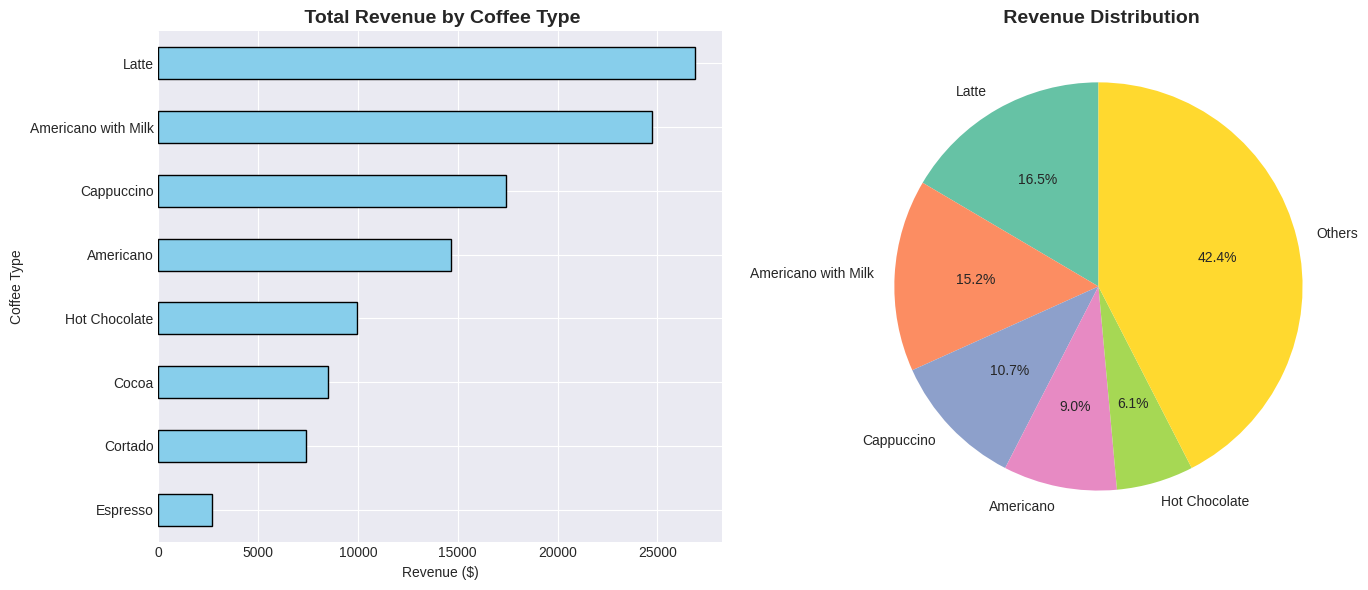

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
coffee_revenue = df.groupby('coffee_name')['money'].sum().sort_values(ascending=True)
coffee_revenue.plot(kind='barh', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title(' Total Revenue by Coffee Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Coffee Type')

# Pie chart (top 5 + others)
top_5 = coffee_revenue.nlargest(5)
others = pd.Series({'Others': coffee_revenue[5:].sum()})
pie_data = pd.concat([top_5, others])
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title(' Revenue Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('1_coffee_revenue.png', dpi=300, bbox_inches='tight')
plt.show()


## HOURLY SALES PATTERN

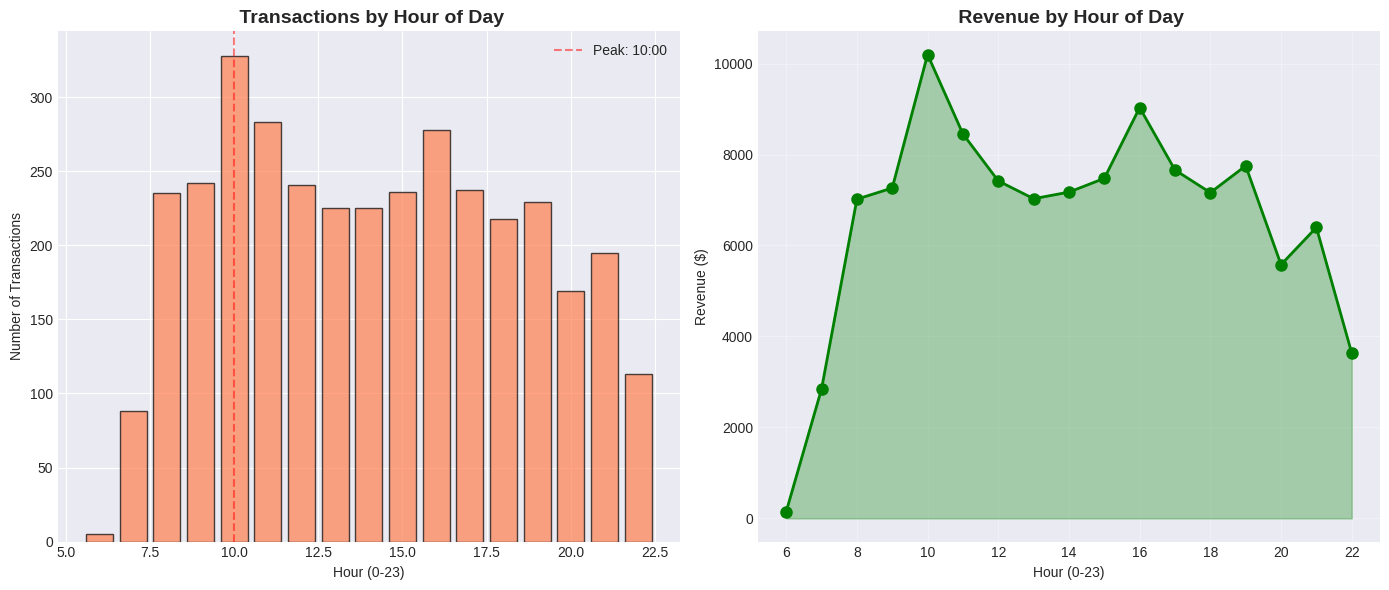


 PEAK HOURS ANALYSIS:
   • 10:00 → 328 transactions
   • 11:00 → 283 transactions
   • 16:00 → 278 transactions


In [13]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Hourly transaction count
hourly_count = df.groupby('hour_of_day').size()
axes[0].bar(hourly_count.index, hourly_count.values, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title(' Transactions by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Number of Transactions')
axes[0].axvline(x=hourly_count.idxmax(), color='red', linestyle='--', alpha=0.5, label=f'Peak: {hourly_count.idxmax()}:00')
axes[0].legend()

# Hourly revenue
hourly_revenue = df.groupby('hour_of_day')['money'].sum()
axes[1].plot(hourly_revenue.index, hourly_revenue.values, marker='o', linewidth=2, color='green', markersize=8)
axes[1].fill_between(hourly_revenue.index, hourly_revenue.values, alpha=0.3, color='green')
axes[1].set_title(' Revenue by Hour of Day', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Revenue ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('2_hourly_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

# Peak hours analysis
print("\n PEAK HOURS ANALYSIS:")
peak_hours = df.groupby('hour_of_day').size().nlargest(3)
for hour, count in peak_hours.items():
    print(f"   • {hour}:00 → {count} transactions")

## WEEKDAY & MONTHLY TRENDS

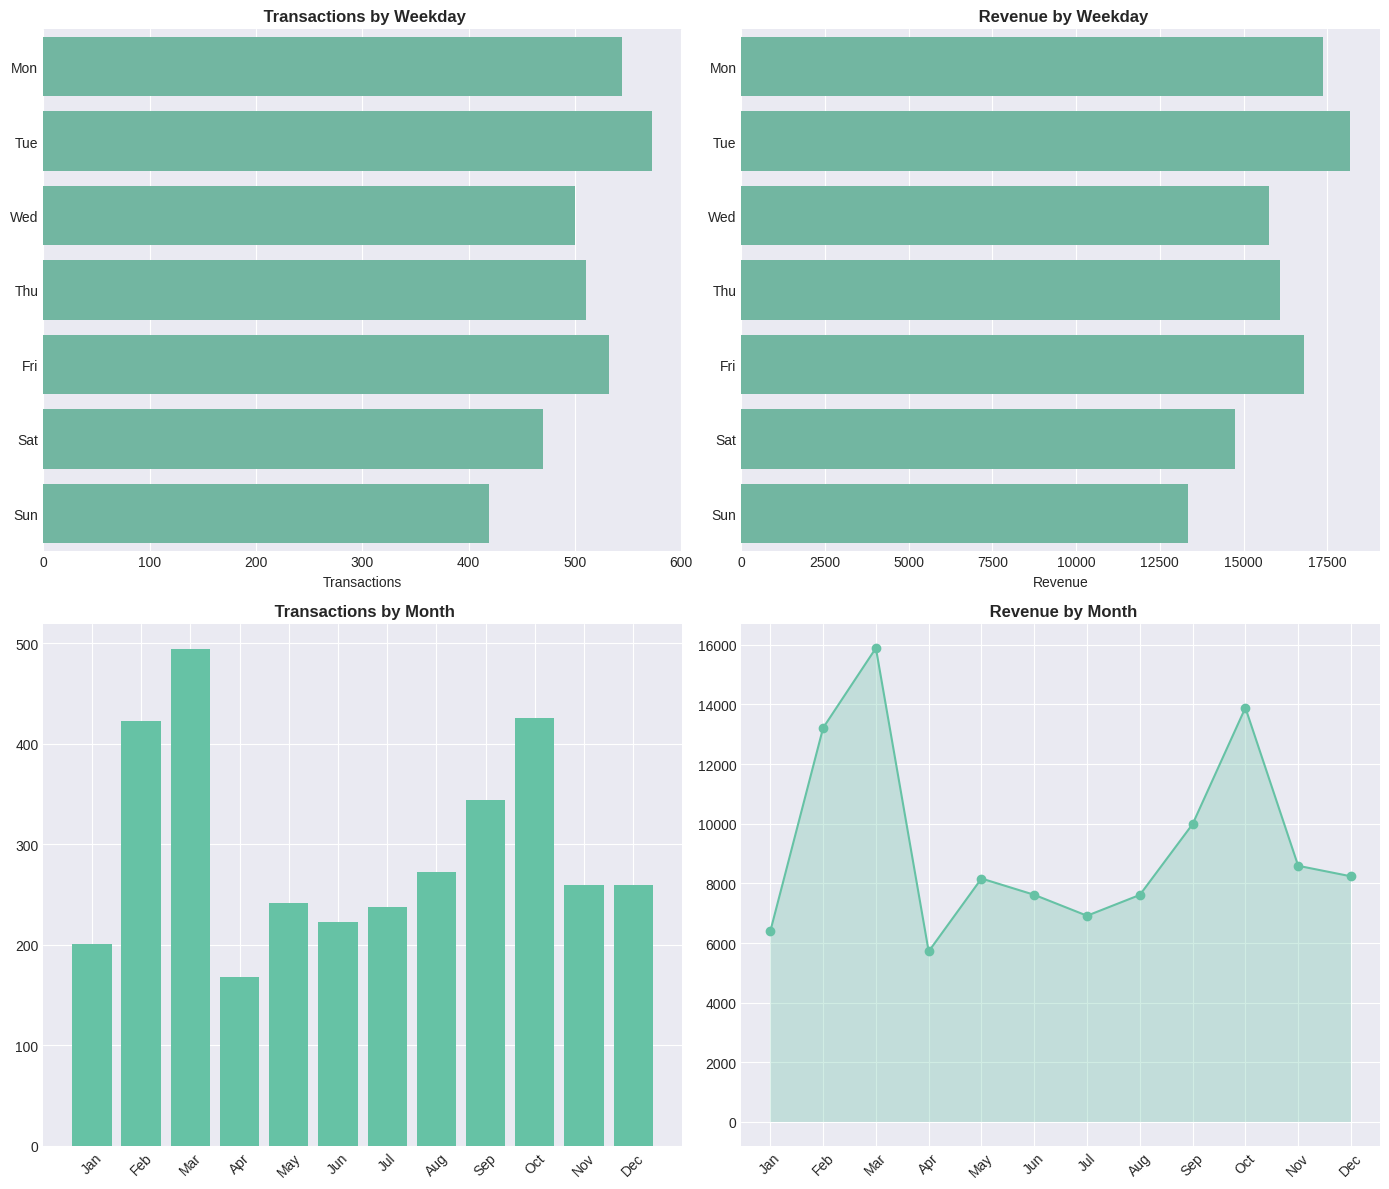

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))


df['Weekday'] = df['Weekday'].astype(str).str.strip()

# Handle both short & full names automatically
short_days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
full_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

if set(df['Weekday'].unique()).issubset(set(short_days)):
    weekday_order = short_days
else:
    mapping = dict(zip(short_days, full_days))
    df['Weekday'] = df['Weekday'].replace(mapping)
    weekday_order = full_days


weekday_count = df.groupby('Weekday').size().reindex(weekday_order).fillna(0)
weekday_revenue = df.groupby('Weekday')['money'].sum().reindex(weekday_order).fillna(0)

sns.barplot(x=weekday_count.values, y=weekday_order, ax=axes[0,0])
axes[0,0].set_title(' Transactions by Weekday', fontweight='bold')
axes[0,0].set_xlabel('Transactions')

sns.barplot(x=weekday_revenue.values, y=weekday_order, ax=axes[0,1])
axes[0,1].set_title(' Revenue by Weekday', fontweight='bold')
axes[0,1].set_xlabel('Revenue')


df['Month_name'] = df['Month_name'].astype(str).str.strip()

short_months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
full_months = ['January','February','March','April','May','June','July','August','September','October','November','December']

if set(df['Month_name'].unique()).issubset(set(short_months)):
    month_order = short_months
else:
    mapping_m = dict(zip(short_months, full_months))
    df['Month_name'] = df['Month_name'].replace(mapping_m)
    month_order = full_months

monthly_count = df.groupby('Month_name').size().reindex(month_order).fillna(0)
monthly_revenue = df.groupby('Month_name')['money'].sum().reindex(month_order).fillna(0)

axes[1,0].bar(month_order, monthly_count.values)
axes[1,0].set_title(' Transactions by Month', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45)

axes[1,1].plot(month_order, monthly_revenue.values, marker='o')
axes[1,1].fill_between(range(len(month_order)), monthly_revenue.values, alpha=0.3)
axes[1,1].set_title(' Revenue by Month', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

## TIME OF DAY ANALYSIS

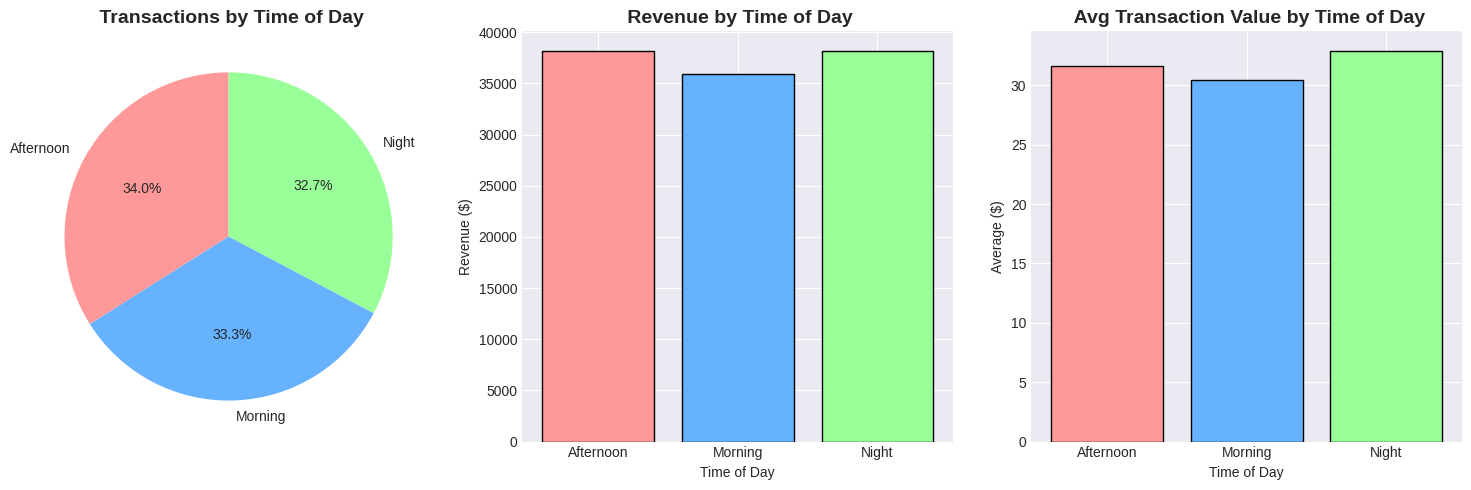

In [15]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Time of day distribution
time_dist = df['Time_of_Day'].value_counts()
colors = ['#FF9999', '#66B2FF', '#99FF99']
axes[0].pie(time_dist.values, labels=time_dist.index, autopct='%1.1f%%', colors=colors[:len(time_dist)], startangle=90)
axes[0].set_title(' Transactions by Time of Day', fontsize=14, fontweight='bold')

# Time of day revenue
time_revenue = df.groupby('Time_of_Day')['money'].sum()
axes[1].bar(time_revenue.index, time_revenue.values, color=colors[:len(time_revenue)], edgecolor='black')
axes[1].set_title(' Revenue by Time of Day', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('Revenue ($)')

# Average transaction value by time of day
time_avg = df.groupby('Time_of_Day')['money'].mean()
axes[2].bar(time_avg.index, time_avg.values, color=colors[:len(time_avg)], edgecolor='black')
axes[2].set_title(' Avg Transaction Value by Time of Day', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time of Day')
axes[2].set_ylabel('Average ($)')

plt.tight_layout()
plt.savefig('4_time_of_day_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


## PAYMENT METHOD ANALYSIS 

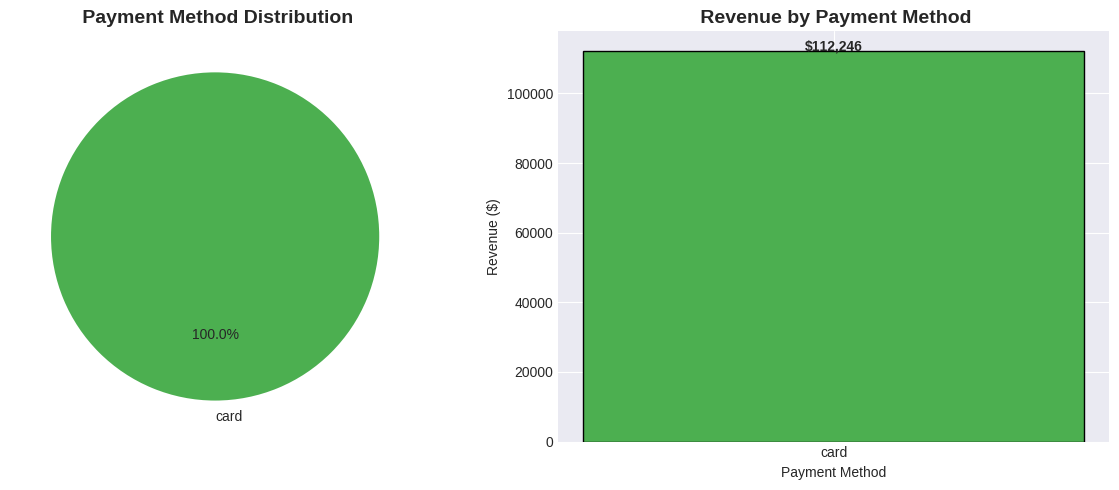

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Payment method distribution
payment_counts = df['cash_type'].value_counts()
num_payments = len(payment_counts)

# Create explode tuple dynamically
if num_payments == 2:
    explode = (0.05, 0)
elif num_payments == 1:
    explode = (0,)
else:
    explode = None

axes[0].pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', 
            colors=['#4CAF50', '#FFC107'][:num_payments], 
            explode=explode if num_payments == 2 else None, 
            startangle=90)
axes[0].set_title(' Payment Method Distribution', fontsize=14, fontweight='bold')

# Revenue by payment method
payment_revenue = df.groupby('cash_type')['money'].sum()
axes[1].bar(payment_revenue.index, payment_revenue.values, color=['#4CAF50', '#FFC107'][:len(payment_revenue)], edgecolor='black')
axes[1].set_title(' Revenue by Payment Method', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Revenue ($)')
for i, v in enumerate(payment_revenue.values):
    axes[1].text(i, v + 100, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('5_payment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


## REVENUE TRENDS OVER TIME

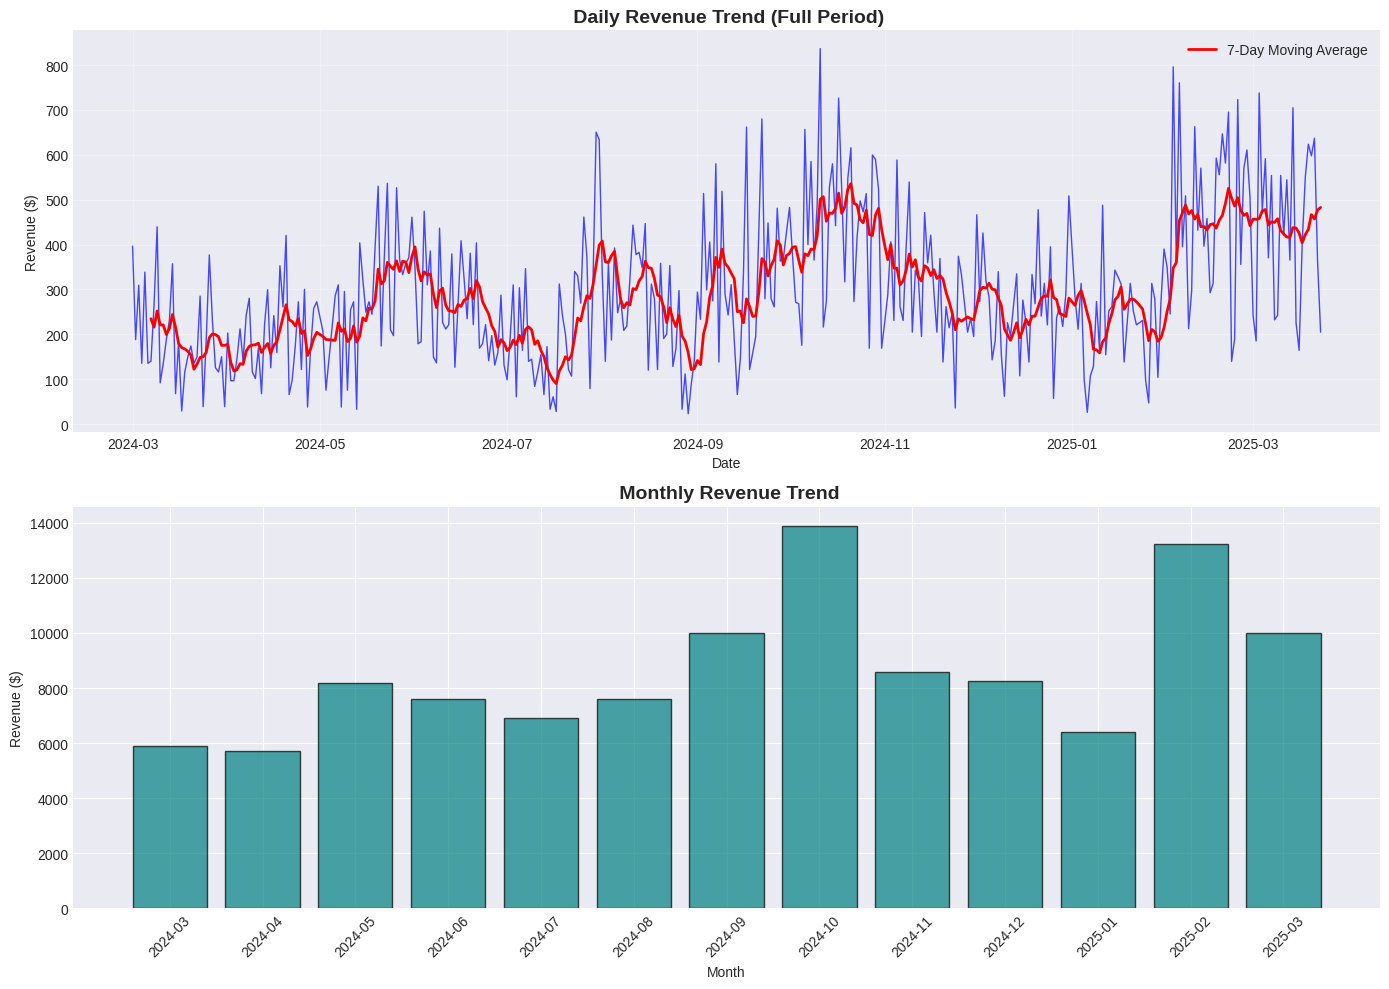

In [17]:

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily revenue trend
daily_revenue = df.groupby('Date')['money'].sum()
axes[0].plot(daily_revenue.index, daily_revenue.values, linewidth=1, color='blue', alpha=0.7)
axes[0].set_title(' Daily Revenue Trend (Full Period)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Revenue ($)')
axes[0].grid(True, alpha=0.3)

# Add rolling average (7-day)
rolling_avg = daily_revenue.rolling(window=7).mean()
axes[0].plot(rolling_avg.index, rolling_avg.values, linewidth=2, color='red', label='7-Day Moving Average')
axes[0].legend()

# Monthly revenue bar chart
monthly_revenue = df.groupby(df['Date'].dt.to_period('M'))['money'].sum()
monthly_revenue.index = monthly_revenue.index.astype(str)
axes[1].bar(monthly_revenue.index, monthly_revenue.values, color='teal', edgecolor='black', alpha=0.7)
axes[1].set_title(' Monthly Revenue Trend', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('6_revenue_trends.png', dpi=300, bbox_inches='tight')
plt.show()


## COFFEE TYPE PREFERENCE BY TIME (FIXED)

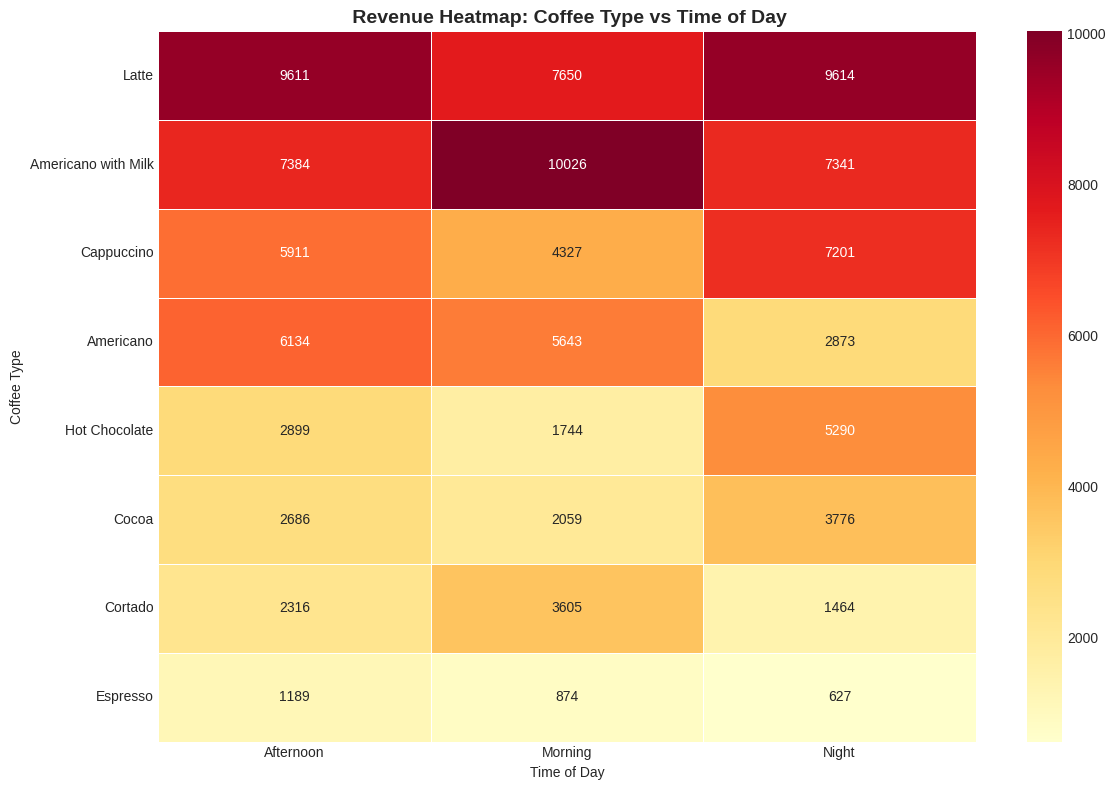

In [18]:

# Create a heatmap of coffee types by time of day - FIXED without fill_value
coffee_time_matrix = pd.crosstab(df['coffee_name'], df['Time_of_Day'], 
                                  values=df['money'], aggfunc='sum')

# Fill NaN values with 0
coffee_time_matrix = coffee_time_matrix.fillna(0)

# Get top 10 coffee types
top_coffees = df.groupby('coffee_name')['money'].sum().nlargest(10).index
coffee_time_top = coffee_time_matrix.loc[top_coffees]

plt.figure(figsize=(12, 8))
sns.heatmap(coffee_time_top, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title(' Revenue Heatmap: Coffee Type vs Time of Day', fontsize=14, fontweight='bold')
plt.xlabel('Time of Day')
plt.ylabel('Coffee Type')
plt.tight_layout()
plt.savefig('7_coffee_time_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## BEST SELLING COFFEE BY TIME PERIOD

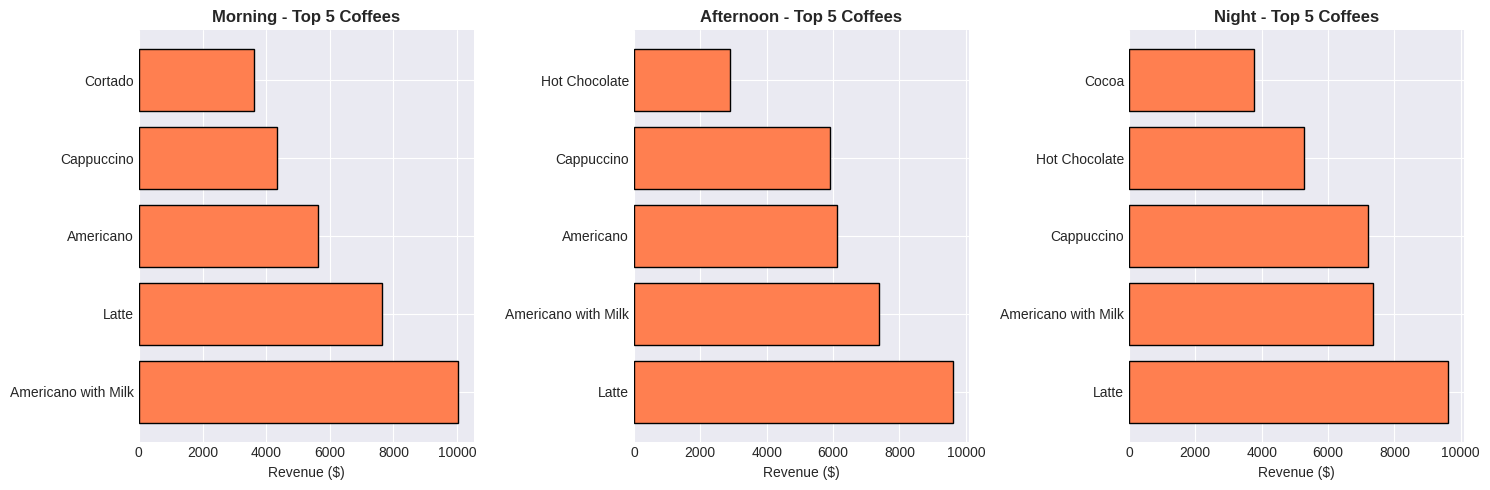

In [19]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, time_period in enumerate(['Morning', 'Afternoon', 'Night']):
    period_data = df[df['Time_of_Day'] == time_period]
    top_coffee = period_data.groupby('coffee_name')['money'].sum().nlargest(5)
    
    axes[idx].barh(range(len(top_coffee)), top_coffee.values, color='coral', edgecolor='black')
    axes[idx].set_yticks(range(len(top_coffee)))
    axes[idx].set_yticklabels(top_coffee.index)
    axes[idx].set_title(f'{time_period} - Top 5 Coffees', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Revenue ($)')

plt.tight_layout()
plt.savefig('8_top_coffee_by_time.png', dpi=300, bbox_inches='tight')
plt.show()

## INTERACTIVE PLOTLY DASHBOARD

In [20]:

# Create interactive time series
fig = px.line(df.groupby('Date')['money'].sum().reset_index(), 
              x='Date', y='money', 
              title=' Interactive Daily Revenue Trend',
              labels={'money': 'Revenue ($)', 'Date': 'Date'})
fig.update_traces(line=dict(color='blue', width=2))
fig.update_layout(template='plotly_white', hovermode='x unified')
fig.write_html('interactive_revenue_trend.html')
fig.show()

# Interactive coffee type comparison
coffee_stats = df.groupby('coffee_name').agg({
    'money': ['sum', 'mean', 'count']
}).round(2)
coffee_stats.columns = ['Total Revenue', 'Avg Transaction', 'Transaction Count']
coffee_stats = coffee_stats.sort_values('Total Revenue', ascending=False).head(10)

fig = px.bar(coffee_stats.reset_index(), 
             x='coffee_name', y='Total Revenue',
             title=' Top 10 Coffee Types by Revenue',
             labels={'coffee_name': 'Coffee Type', 'Total Revenue': 'Total Revenue ($)'},
             text='Total Revenue',
             color='Total Revenue',
             color_continuous_scale='Viridis')
fig.update_traces(textposition='outside')
fig.update_layout(template='plotly_white', xaxis_tickangle=-45)
fig.write_html('interactive_coffee_revenue.html')
fig.show()

# Interactive hourly heatmap
hourly_weekday = pd.crosstab(df['hour_of_day'], df['Weekday'], values=df['money'], aggfunc='sum').fillna(0)
fig = px.imshow(hourly_weekday.values, 
                x=hourly_weekday.columns,
                y=hourly_weekday.index,
                title=' Revenue Heatmap: Hour vs Weekday',
                labels=dict(x="Weekday", y="Hour of Day", color="Revenue ($)"),
                color_continuous_scale='Viridis')
fig.update_layout(height=500)
fig.write_html('interactive_hourly_heatmap.html')
fig.show()

In [21]:


print("\n TOP PERFORMING PRODUCTS:")
top_coffee_revenue = df.groupby('coffee_name')['money'].sum().nlargest(3)
for coffee, revenue in top_coffee_revenue.items():
    print(f"   • {coffee}: ${revenue:,.2f}")

print("\n PEAK BUSINESS HOURS:")
for hour, count in peak_hours.items():
    print(f"   • {hour}:00 ({count} transactions)")

print("\n BEST PERFORMING DAYS:")
top_days = df.groupby('Weekday')['money'].sum().nlargest(2)
for day, revenue in top_days.items():
    print(f"   • {day}: ${revenue:,.2f}")

print("\n TIME OF DAY INSIGHTS:")
for time, count in time_dist.items():
    avg_value = df[df['Time_of_Day'] == time]['money'].mean()
    print(f"   • {time}: {count} transactions (Avg ${avg_value:.2f})")



# Save cleaned data for Power BI/Tableau
df_cleaned = df.copy()
df_cleaned.to_csv('coffee_sales_cleaned.csv', index=False)
print("\n Cleaned data exported to 'coffee_sales_cleaned.csv'")

# Create summary file for quick reference
summary = pd.DataFrame({
    'Metric': ['Total Revenue', 'Total Transactions', 'Avg Transaction Value', 
               'Card %', 'Cash %', 'Unique Coffee Types', 'Date Range'],
    'Value': [f'${total_revenue:,.2f}', total_transactions, f'${avg_transaction_value:.2f}',
              f'{card_percentage:.1f}%', f'{cash_percentage:.1f}%', unique_coffee_types,
              f"{df['Date'].min()} to {df['Date'].max()}"]
})
summary.to_csv('dashboard_summary.csv', index=False)
print(" Summary metrics exported to 'dashboard_summary.csv'")


print(" ANALYSIS COMPLETE! Check the generated files:")
print("   - 9 visualization images (.png)")
print("   - 3 interactive HTML dashboards")
print("   - 2 CSV files for dashboarding")



 TOP PERFORMING PRODUCTS:
   • Latte: $26,875.30
   • Americano with Milk: $24,751.12
   • Cappuccino: $17,439.14

 PEAK BUSINESS HOURS:
   • 10:00 (328 transactions)
   • 11:00 (283 transactions)
   • 16:00 (278 transactions)

 BEST PERFORMING DAYS:
   • Tue: $18,168.38
   • Mon: $17,363.10

 TIME OF DAY INSIGHTS:
   • Afternoon: 1205 transactions (Avg $31.64)
   • Morning: 1181 transactions (Avg $30.42)
   • Night: 1161 transactions (Avg $32.89)

 Cleaned data exported to 'coffee_sales_cleaned.csv'
 Summary metrics exported to 'dashboard_summary.csv'
 ANALYSIS COMPLETE! Check the generated files:
   - 9 visualization images (.png)
   - 3 interactive HTML dashboards
   - 2 CSV files for dashboarding


In [22]:

# Sort by date (CRITICAL for time series)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"\n Dataset Shape: {df.shape}")
print(f" Date Range: {df['Date'].min()} to {df['Date'].max()}")

# Remove outliers (IQR method)
Q1 = df['money'].quantile(0.25)
Q3 = df['money'].quantile(0.75)
IQR = Q3 - Q1
outliers_before = len(df)
df = df[(df['money'] >= Q1 - 1.5*IQR) & (df['money'] <= Q3 + 1.5*IQR)]
print(f" Removed {outliers_before - len(df)} outliers")

# Normalize money (log transform)
df['money_log'] = np.log1p(df['money'])


 Dataset Shape: (3547, 13)
 Date Range: 2024-03-01 00:00:00 to 2025-03-23 00:00:00
 Removed 0 outliers


# FEATURE ENGINEERING

In [23]:

# Time-based features
df['is_weekend'] = df['Weekday'].isin(['Saturday', 'Sunday']).astype(int)
df['is_peak_hour'] = df['hour_of_day'].between(10, 16).astype(int)
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['day_of_year'] = df['Date'].dt.dayofyear
df['week_of_year'] = df['Date'].dt.isocalendar().week

# Revenue segmentation
df['spending_level'] = pd.qcut(df['money'], q=3, labels=['Low', 'Medium', 'High'])

# Coffee popularity rank
coffee_rank = df['coffee_name'].value_counts().rank(method='dense')
df['coffee_rank'] = df['coffee_name'].map(coffee_rank).astype(int)

# Month sin/cos for seasonality
df['month_sin'] = np.sin(2 * np.pi * df['Date'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Date'].dt.month / 12)

print(" Added 10+ engineered features:")
print("   • is_weekend, is_peak_hour")
print("   • hour_sin, hour_cos (cyclical encoding)")
print("   • spending_level (Low/Medium/High)")
print("   • coffee_rank (popularity score)")
print("   • month_sin, month_cos (seasonality)")
print("   • money_log (normalized revenue)")


 Added 10+ engineered features:
   • is_weekend, is_peak_hour
   • hour_sin, hour_cos (cyclical encoding)
   • spending_level (Low/Medium/High)
   • coffee_rank (popularity score)
   • month_sin, month_cos (seasonality)
   • money_log (normalized revenue)


# CUSTOMER BEHAVIOR ANALYSIS

In [24]:


# Simulate customer IDs
np.random.seed(42)
df['customer_id'] = np.random.randint(1000, 2000, size=len(df))

# Customer segmentation
customer_stats = df.groupby('customer_id').agg({
    'money': ['sum', 'mean', 'count'],
    'is_weekend': 'mean',
    'is_peak_hour': 'mean'
}).round(2)

customer_stats.columns = ['total_spent', 'avg_spent', 'transaction_count', 
                          'weekend_ratio', 'peak_hour_ratio']

# RFM-style segmentation
customer_stats['customer_value'] = pd.qcut(customer_stats['total_spent'], 
                                            q=4, labels=['Bronze', 'Silver', 'Gold', 'Platinum'])

# High-value customers
high_value = customer_stats[customer_stats['customer_value'] == 'Platinum']
high_value_revenue_pct = (high_value['total_spent'].sum() / customer_stats['total_spent'].sum()) * 100

print(f"\n Customer Statistics:")
print(f"   • Total unique customers: {len(customer_stats):,}")
print(f"   • Average spend per customer: ${customer_stats['total_spent'].mean():.2f}")
print(f"   • Average transactions per customer: {customer_stats['transaction_count'].mean():.1f}")
print(f"   •  High-value customers (Platinum): {len(high_value)} customers")
print(f"   •  High-value customers contribute: {high_value_revenue_pct:.1f}% of total revenue")

# Loyalty analysis
repeat_customers = customer_stats[customer_stats['transaction_count'] > 1]
print(f"   •  Repeat customers: {len(repeat_customers)} ({len(repeat_customers)/len(customer_stats)*100:.1f}%)")



 Customer Statistics:
   • Total unique customers: 959
   • Average spend per customer: $117.04
   • Average transactions per customer: 3.7
   •  High-value customers (Platinum): 240 customers
   •  High-value customers contribute: 42.5% of total revenue
   •  Repeat customers: 848 (88.4%)


# MODEL

In [25]:

# Prepare features for ML
df_ml = df.copy()

# Encode categorical variables
categorical_cols = ['coffee_name', 'cash_type', 'Time_of_Day', 'Weekday', 'spending_level']
df_ml = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True)

# Select features
feature_cols = ['hour_of_day', 'is_weekend', 'is_peak_hour', 'coffee_rank',
                'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_year']
feature_cols += [col for col in df_ml.columns if any(cat in col for cat in 
                  ['coffee_name_', 'cash_type_', 'Time_of_Day_', 'Weekday_', 'spending_level_'])]

X = df_ml[feature_cols]
y = df_ml['money']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Gradient Boosting Model
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)
gb_preds = gb_model.predict(X_test)

# Metrics
print("\n Model Performance:")
print(f"   Random Forest - MAE: ${mean_absolute_error(y_test, rf_preds):.2f}")
print(f"   Random Forest - RMSE: ${np.sqrt(mean_squared_error(y_test, rf_preds)):.2f}")
print(f"   Random Forest - R²: {r2_score(y_test, rf_preds):.3f}")
print(f"\n   Gradient Boosting - MAE: ${mean_absolute_error(y_test, gb_preds):.2f}")
print(f"   Gradient Boosting - R²: {r2_score(y_test, gb_preds):.3f}")

# Cross-validation
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print(f"\n    Cross-validation R² (5-fold): {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")



 Model Performance:
   Random Forest - MAE: $0.06
   Random Forest - RMSE: $0.30
   Random Forest - R²: 0.996

   Gradient Boosting - MAE: $0.25
   Gradient Boosting - R²: 0.993

    Cross-validation R² (5-fold): 0.903 (+/- 0.168)


# FEATURE IMPORTANCE ANALYSIS


 Top 10 Features Affecting Revenue:
   26. spending_level_High: 0.537
   25. spending_level_Medium: 0.284
   4. coffee_rank: 0.080
   8. month_cos: 0.034
   10. coffee_name_Americano with Milk: 0.025
   9. day_of_year: 0.021
   7. month_sin: 0.015
   14. coffee_name_Espresso: 0.002
   13. coffee_name_Cortado: 0.001
   5. hour_sin: 0.000


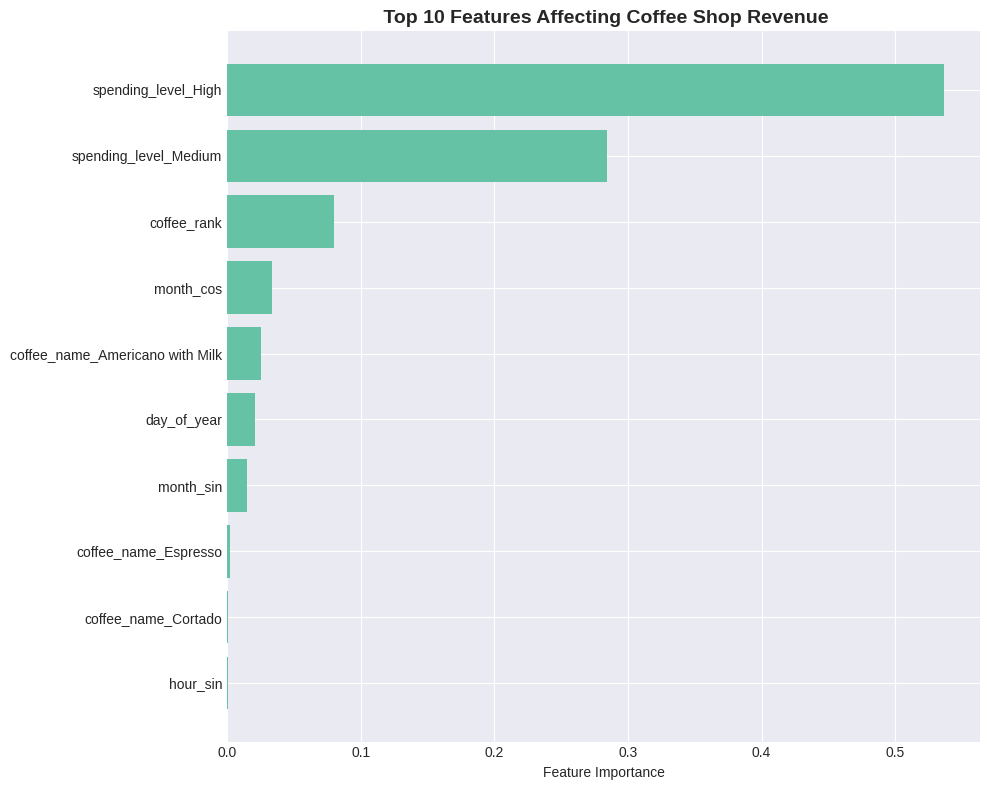

In [26]:



importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n Top 10 Features Affecting Revenue:")
for i, row in importances.head(10).iterrows():
    print(f"   {i+1}. {row['feature']}: {row['importance']:.3f}")

# Visualization
plt.figure(figsize=(10, 8))
top_features = importances.head(10)
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Feature Importance')
plt.title(' Top 10 Features Affecting Coffee Shop Revenue', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


# TIME SERIES FORECASTING


 Next 7 Days Revenue Forecast:
   • 2025-03-24: $453.97
   • 2025-03-25: $492.85
   • 2025-03-26: $494.08
   • 2025-03-27: $488.77
   • 2025-03-28: $468.04
   • 2025-03-29: $423.49
   • 2025-03-30: $424.72

 Total forecasted revenue (next 7 days): $3245.92


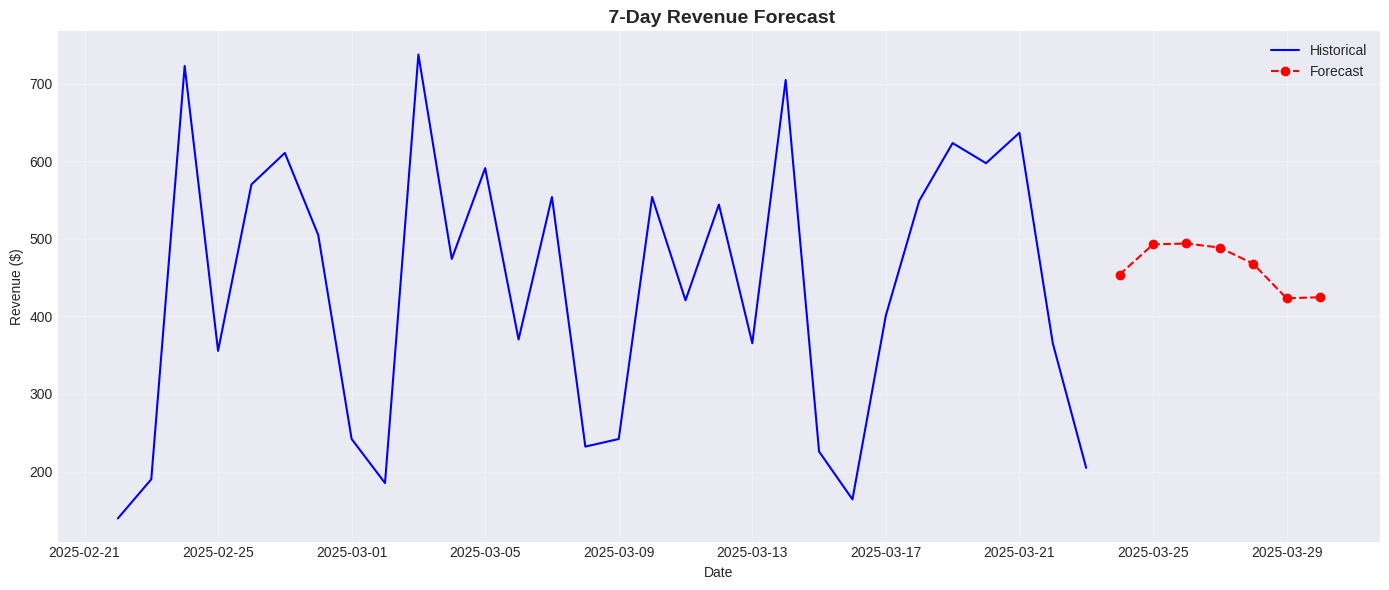

In [27]:

# Daily aggregated revenue
daily_revenue = df.groupby('Date')['money'].sum()

# Fill missing days with 0
all_dates = pd.date_range(start=daily_revenue.index.min(), end=daily_revenue.index.max(), freq='D')
daily_revenue = daily_revenue.reindex(all_dates, fill_value=0)

# Fit ARIMA model
try:
    model = ARIMA(daily_revenue, order=(5,1,2))
    model_fit = model.fit()
    
    # Forecast next 7 days
    forecast = model_fit.forecast(steps=7)
    forecast_dates = pd.date_range(start=daily_revenue.index[-1] + pd.Timedelta(days=1), periods=7, freq='D')
    
    print(f"\n Next 7 Days Revenue Forecast:")
    for date, revenue in zip(forecast_dates, forecast):
        print(f"   • {date.strftime('%Y-%m-%d')}: ${revenue:.2f}")
    
    print(f"\n Total forecasted revenue (next 7 days): ${forecast.sum():.2f}")
    
    # Visualization
    plt.figure(figsize=(14, 6))
    plt.plot(daily_revenue.index[-30:], daily_revenue.values[-30:], label='Historical', color='blue')
    plt.plot(forecast_dates, forecast, label='Forecast', color='red', linestyle='--', marker='o')
    plt.title(' 7-Day Revenue Forecast', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Revenue ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('revenue_forecast.png', dpi=300, bbox_inches='tight')
    plt.show()
    
except Exception as e:
    print(f"Note: ARIMA model requires more data points. {str(e)}")


# CUSTOMER SEGMENTATION (K-Means Clustering)

In [28]:


# Prepare data for clustering
cluster_data = customer_stats[['total_spent', 'avg_spent', 'transaction_count', 'weekend_ratio']].copy()
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

# K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_stats['segment'] = kmeans.fit_predict(cluster_scaled)

# Map segments to meaningful names
segment_names = {
    0: 'Budget Regulars',
    1: 'Weekend Spenders',
    2: 'Premium Loyal'
}
customer_stats['segment_name'] = customer_stats['segment'].map(segment_names)

print("\n Customer Segments:")
for segment in customer_stats['segment_name'].unique():
    segment_data = customer_stats[customer_stats['segment_name'] == segment]
    print(f"\n    {segment}:")
    print(f"      • Customers: {len(segment_data)}")
    print(f"      • Avg spend: ${segment_data['total_spent'].mean():.2f}")
    print(f"      • Avg transactions: {segment_data['transaction_count'].mean():.1f}")
    print(f"      • Weekend ratio: {segment_data['weekend_ratio'].mean():.1%}")



 Customer Segments:

    Budget Regulars:
      • Customers: 270
      • Avg spend: $193.16
      • Avg transactions: 6.1
      • Weekend ratio: 0.0%

    Premium Loyal:
      • Customers: 284
      • Avg spend: $74.79
      • Avg transactions: 2.6
      • Weekend ratio: 0.0%

    Weekend Spenders:
      • Customers: 405
      • Avg spend: $95.93
      • Avg transactions: 2.9
      • Weekend ratio: 0.0%


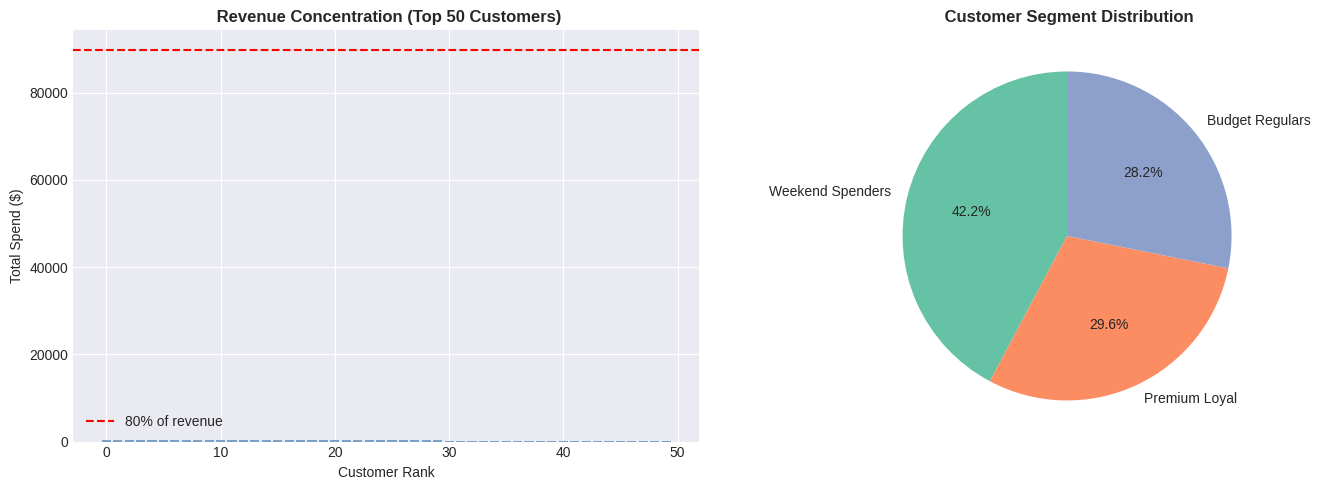

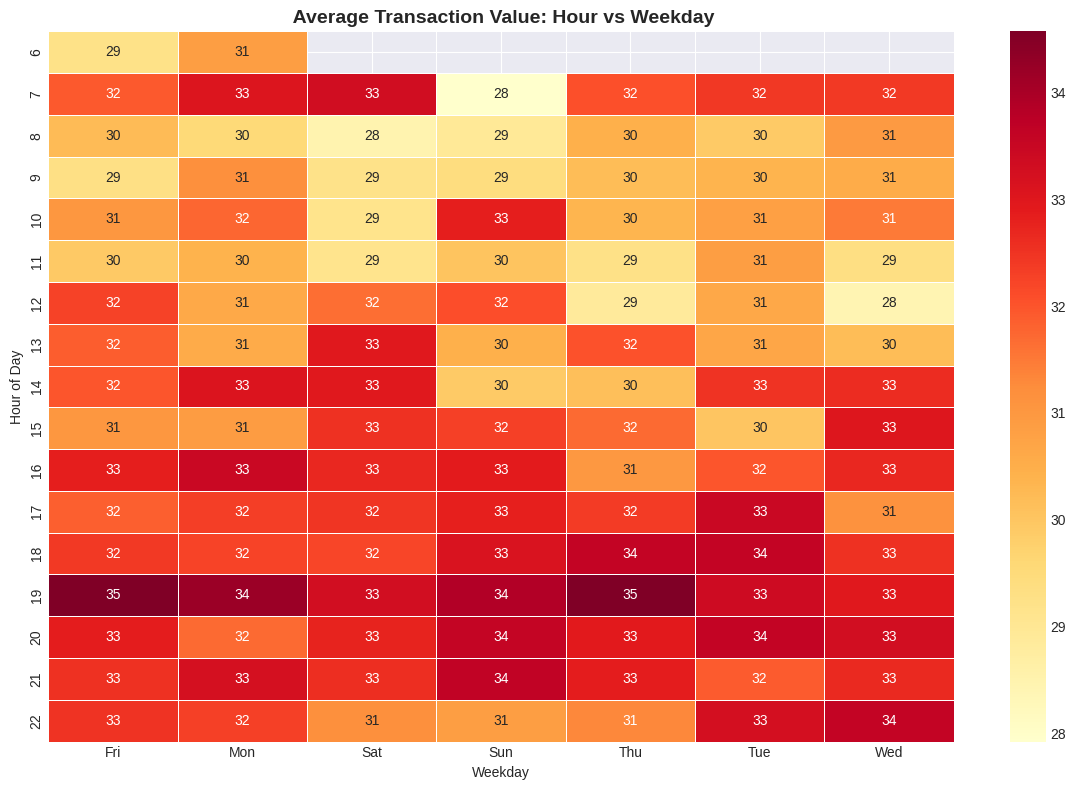

In [29]:

# Customer Value Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pareto chart (80/20 rule)
sorted_spend = customer_stats['total_spent'].sort_values(ascending=False)
cumulative_pct = sorted_spend.cumsum() / sorted_spend.sum() * 100

axes[0].bar(range(len(sorted_spend[:50])), sorted_spend.values[:50], alpha=0.7, color='steelblue')
axes[0].axhline(y=sorted_spend.sum() * 0.8, color='red', linestyle='--', label='80% of revenue')
axes[0].set_title(' Revenue Concentration (Top 50 Customers)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Customer Rank')
axes[0].set_ylabel('Total Spend ($)')
axes[0].legend()

# Customer segment pie chart
segment_counts = customer_stats['segment_name'].value_counts()
axes[1].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title(' Customer Segment Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('customer_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Hourly spending pattern by weekday heatmap
hour_weekday_pivot = df.pivot_table(values='money', index='hour_of_day', 
                                     columns='Weekday', aggfunc='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(hour_weekday_pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title(' Average Transaction Value: Hour vs Weekday', fontsize=14, fontweight='bold')
plt.xlabel('Weekday')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.savefig('hour_weekday_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

